In [1]:
# Basic Libraries
import numpy as np
import pandas as pd
import seaborn as sb
import matplotlib.pyplot as plt # we only need pyplot
sb.set() # set the default Seaborn style for graphics

In [5]:
houseData = pd.read_csv('train.csv')

In [6]:
houseGrLivArea = pd.DataFrame(houseData['GrLivArea'])
houseSalePrice = pd.DataFrame(houseData['SalePrice'])

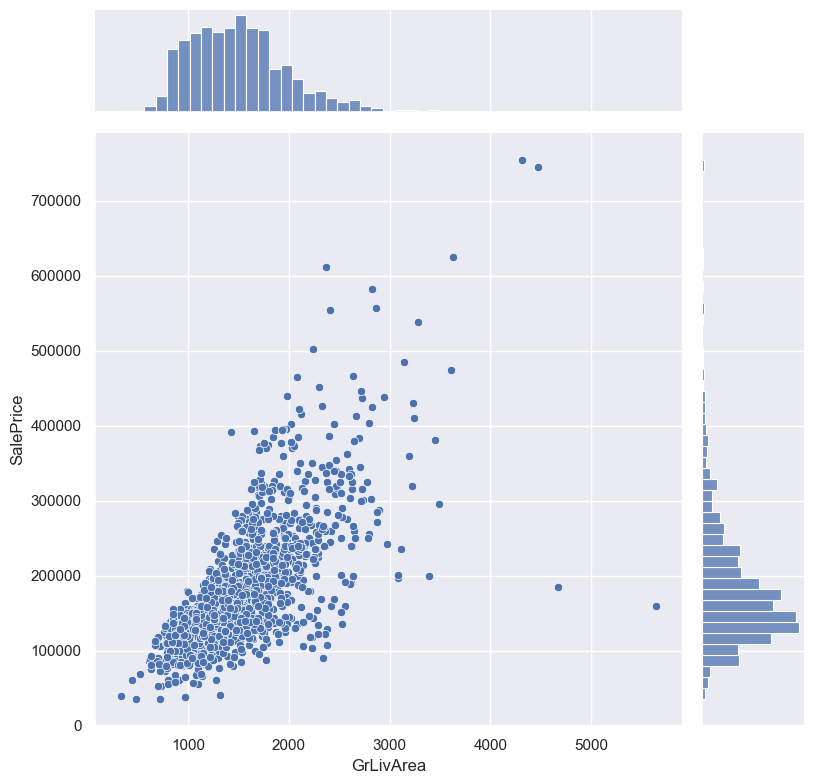

In [7]:
sb.jointplot(x=houseData['GrLivArea'], y=houseData['SalePrice'], height = 8)

In [11]:
from sklearn.linear_model import LinearRegression

In [25]:
from sklearn.model_selection import train_test_split
from sklearn.metrics import mean_squared_error

livArea_train, livArea_test, sale_train, sale_test = train_test_split(houseGrLivArea, houseSalePrice, test_size = 0.25)

In [26]:
linreg = LinearRegression()

In [27]:
linreg.fit(livArea_train, sale_train)

,fit_intercept,True
,copy_X,True
,tol,1e-06
,n_jobs,None
,positive,False


In [28]:
# Coefficients of the Linear Regression line
print('Intercept \t: b = ', linreg.intercept_)
print('Coefficients \t: a = ', linreg.coef_)

Intercept 	: b =  [19583.98146158]
Coefficients 	: a =  [[106.31652029]]


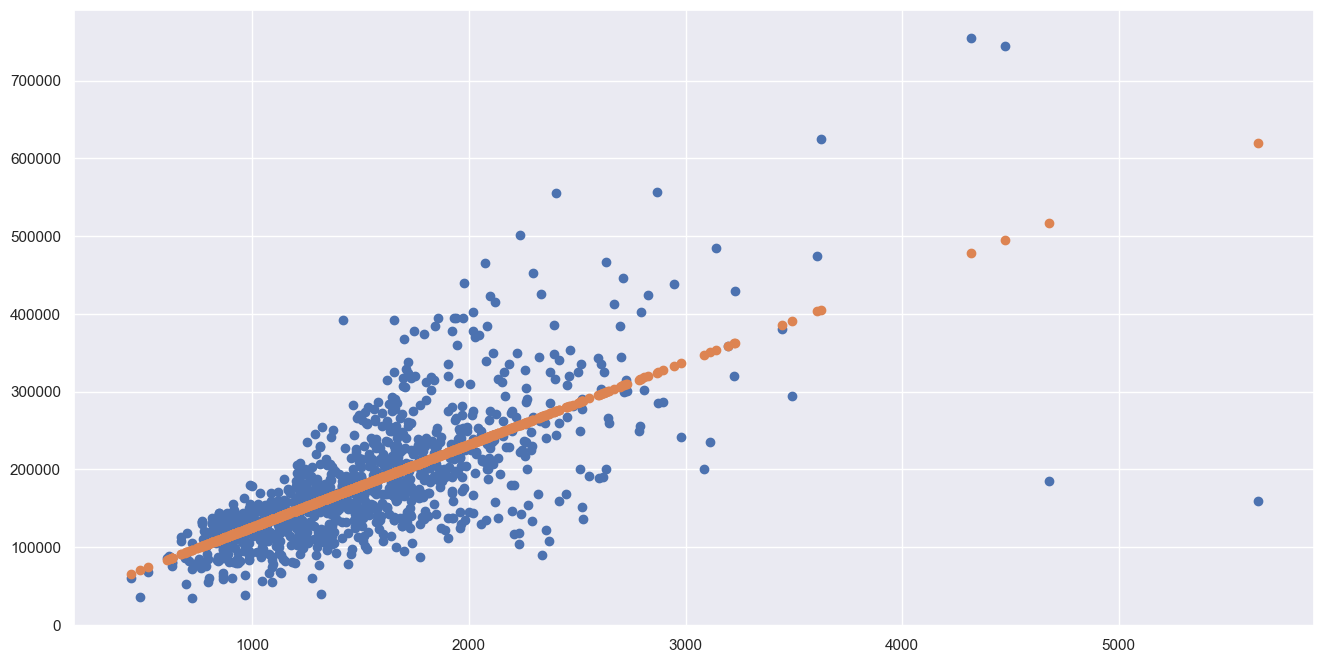

In [29]:
# Formula for the Regression line
regline_x = livArea_train
regline_y = linreg.intercept_ + linreg.coef_ * livArea_train

# Plot the Linear Regression line
f, axes = plt.subplots(1, 1, figsize=(16, 8))
plt.scatter(livArea_train, sale_train)
plt.scatter(regline_x, regline_y)
plt.show()

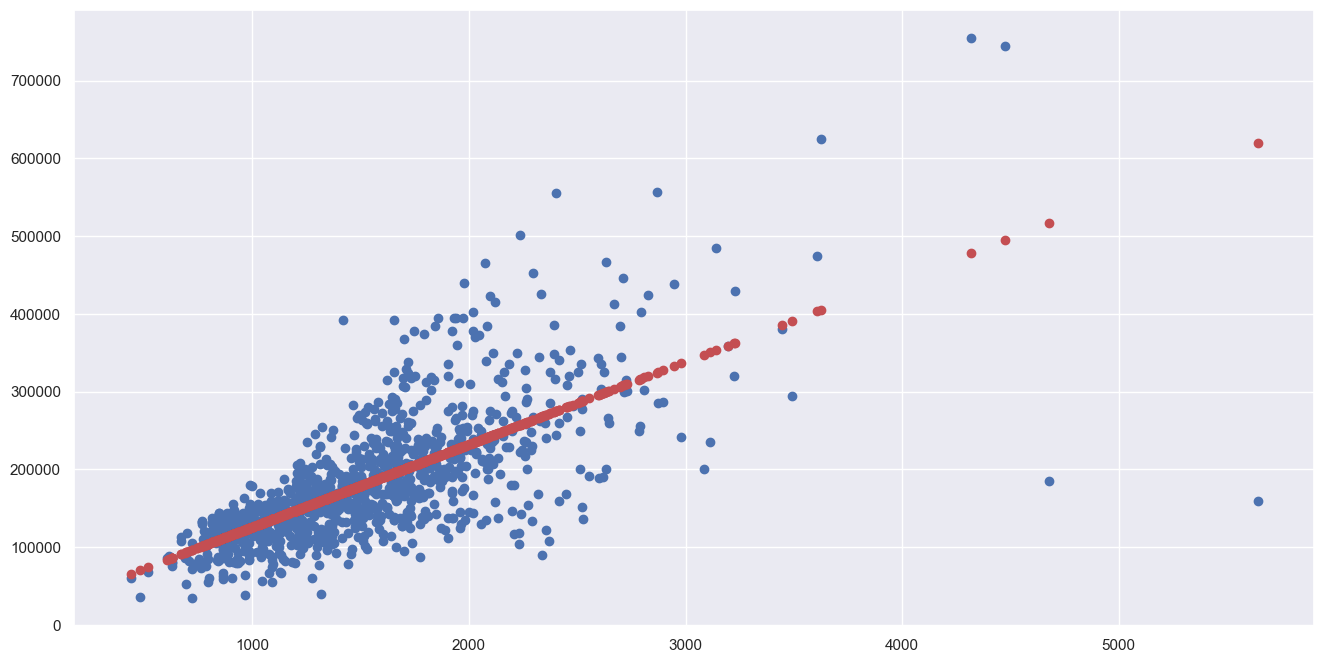

In [30]:
# Predict Total values corresponding to HP Train
sale_train_pred = linreg.predict(livArea_train)

# Plot the Linear Regression line
f, axes = plt.subplots(1, 1, figsize=(16, 8))
plt.scatter(livArea_train, sale_train)
plt.scatter(livArea_train, sale_train_pred, color = "r")
plt.show()

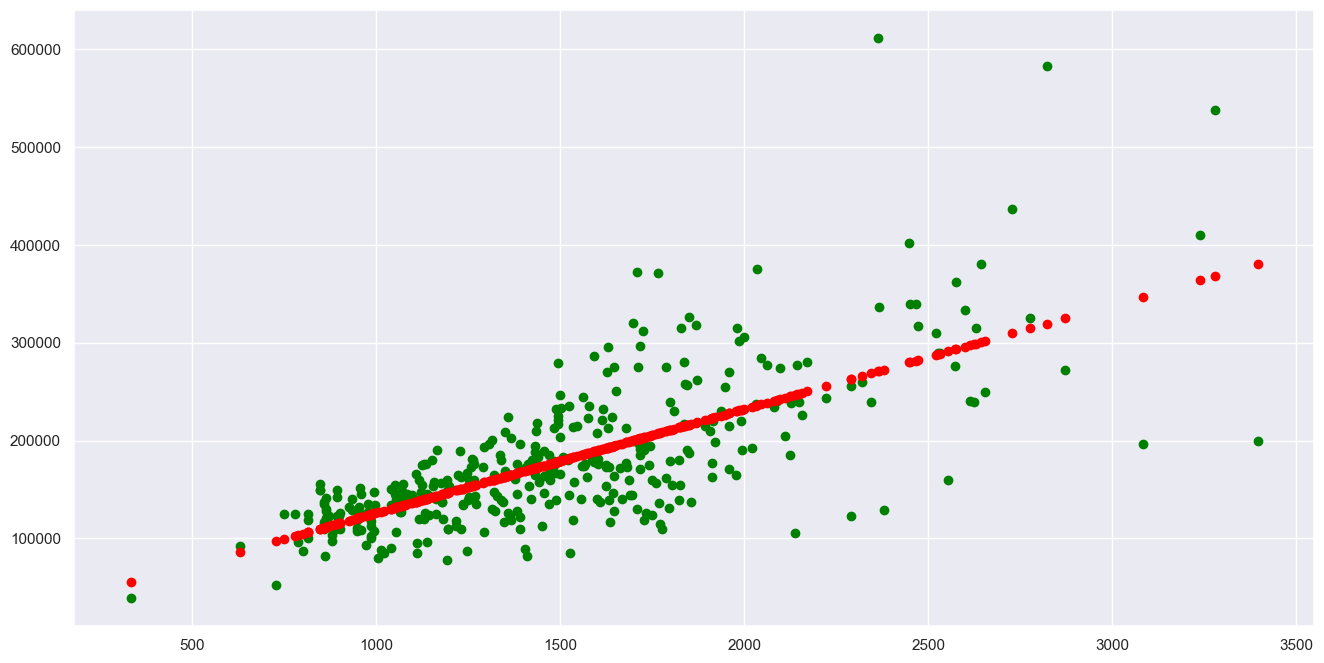

In [31]:
# Predict Total values corresponding to HP Test
sale_test_pred = linreg.predict(livArea_test)

# Plot the Predictions
f, axes = plt.subplots(1, 1, figsize=(16, 8))
plt.scatter(livArea_test, sale_test, color = "green")
plt.scatter(livArea_test, sale_test_pred, color = "red")
plt.show()

In [32]:
# Explained Variance (R^2) WHAT IS LINREG? 
print("Explained Variance (R^2) \t:", linreg.score(livArea_train, sale_train))

# Mean Squared Error (MSE)
def mean_sq_err(actual, predicted):
    '''Returns the Mean Squared Error of actual and predicted values'''
    return np.mean(np.square(np.array(actual) - np.array(predicted)))


mse = mean_sq_err(sale_train, sale_train_pred)
print("Mean Squared Error (MSE) \t:", mse)
print("Root Mean Squared Error (RMSE) \t:", np.sqrt(mse))

Explained Variance (R^2) 	: 0.497321857995381
Mean Squared Error (MSE) 	: 3281841730.1142616
Root Mean Squared Error (RMSE) 	: 57287.36099799206


In [33]:
# Explained Variance (R^2)
print("Explained Variance (R^2) \t:", linreg.score(livArea_test, sale_test))

# Mean Squared Error (MSE)
def mean_sq_err(actual, predicted):
    '''Returns the Mean Squared Error of actual and predicted values'''
    return np.mean(np.square(np.array(actual) - np.array(predicted)))

mse = mean_sq_err(sale_test, sale_test_pred)
print("Mean Squared Error (MSE) \t:", mse)
print("Root Mean Squared Error (RMSE) \t:", np.sqrt(mse))

Explained Variance (R^2) 	: 0.5187408375169675
Mean Squared Error (MSE) 	: 2714769478.9179463
Root Mean Squared Error (RMSE) 	: 52103.449779433475
